<a href="https://colab.research.google.com/github/RfAc45/nomina-inteligente/blob/main/CIA6041_NominaInteligente_ETL_EDAb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head()

Filas: 1470 | Columnas: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
vacios = df.isnull().sum()
print("Total de valores vacíos en todo el dataset:", vacios.sum())

duplicados = df.duplicated().sum()
print("Filas duplicadas:", duplicados)

Total de valores vacíos en todo el dataset: 0
Filas duplicadas: 0


In [6]:
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes encontradas:", constantes)

for col in constantes:
    print(f"  {col}: valor único = {df[col].unique()[0]}")

Columnas constantes encontradas: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: valor único = 1
  Over18: valor único = Y
  StandardHours: valor único = 80


In [7]:
df_limpio = df.drop(columns=constantes)

print("Columnas antes:", df.shape[1], "| Columnas después:", df_limpio.shape[1])
print("Se eliminaron:", constantes)

Columnas antes: 35 | Columnas después: 32
Se eliminaron: ['EmployeeCount', 'Over18', 'StandardHours']


In [8]:
assert df_limpio.shape[0] == df.shape[0], "¡Se perdieron filas al limpiar!"
print("Filas verificadas: ninguna se perdió.", df_limpio.shape[0], "empleados intactos.")

Filas verificadas: ninguna se perdió. 1470 empleados intactos.


In [9]:
def banda_salarial(ingreso):
    if ingreso < 3000:
        return "Bajo"
    elif ingreso < 8000:
        return "Medio"
    else:
        return "Alto"

def grupo_antiguedad(anios):
    if anios < 3:
        return "Nuevo"
    elif anios < 10:
        return "Intermedio"
    else:
        return "Senior"

df_limpio["Banda salarial"] = df_limpio["MonthlyIncome"].apply(banda_salarial)
df_limpio["Grupo de antigüedad"] = df_limpio["YearsAtCompany"].apply(grupo_antiguedad)

df_limpio[["MonthlyIncome", "Banda salarial", "YearsAtCompany", "Grupo de antigüedad"]].head(8)

,MonthlyIncome,Banda salarial,YearsAtCompany,Grupo de antigüedad
0,5993,Medio,6,Intermedio
1,5130,Medio,10,Senior
2,2090,Bajo,0,Nuevo
3,2909,Bajo,8,Intermedio
4,3468,Medio,2,Nuevo
5,3068,Medio,7,Intermedio
6,2670,Bajo,1,Nuevo
7,2693,Bajo,1,Nuevo


In [10]:
por_departamento = df_limpio.groupby("Department")["MonthlyIncome"].agg(["count", "mean"]).round(2)
por_departamento.columns = ["Empleados", "Salario promedio"]
por_departamento

,Empleados,Salario promedio
Department,,
Human Resources,63,6654.51
Research & Development,961,6281.25
Sales,446,6959.17


In [11]:
por_antiguedad = df_limpio.groupby("Grupo de antigüedad")["MonthlyIncome"].mean().round(2)
por_antiguedad = por_antiguedad.reindex(["Nuevo", "Intermedio", "Senior"])
por_antiguedad

,MonthlyIncome
Grupo de antigüedad,
Nuevo,4709.34
Intermedio,5851.83
Senior,9534.49


In [12]:
df_limpio["CandidatoPromocion"] = (df_limpio["YearsSinceLastPromotion"] >= 3).astype(int)

candidatos = df_limpio["CandidatoPromocion"].sum()
total = df_limpio.shape[0]
print(f"Empleados candidatos a promoción (3+ años sin ascenso): {candidatos} de {total} ({candidatos/total:.1%})")

Empleados candidatos a promoción (3+ años sin ascenso): 373 de 1470 (25.4%)


In [13]:
candidatos_por_depto = df_limpio.groupby("Department")["CandidatoPromocion"].agg(["sum", "mean"]).round(2)
candidatos_por_depto.columns = ["Cantidad", "Proporción"]
candidatos_por_depto

,Cantidad,Proporción
Department,,
Human Resources,14,0.22
Research & Development,236,0.25
Sales,123,0.28


In [14]:
costo_total_nomina = df_limpio["MonthlyIncome"].sum()
salario_promedio = df_limpio["MonthlyIncome"].mean()
tasa_rotacion = (df_limpio["Attrition"] == "Yes").mean()
empleados_que_renunciaron = (df_limpio["Attrition"] == "Yes").sum()

print(f"Costo total de nómina:      ${costo_total_nomina:,.2f}")
print(f"Salario promedio:           ${salario_promedio:,.2f}")
print(f"Tasa de rotación:           {tasa_rotacion:.2%}")
print(f"Empleados que renunciaron:  {empleados_que_renunciaron}")

Costo total de nómina:      $9,559,309.00
Salario promedio:           $6,502.93
Tasa de rotación:           16.12%
Empleados que renunciaron:  237


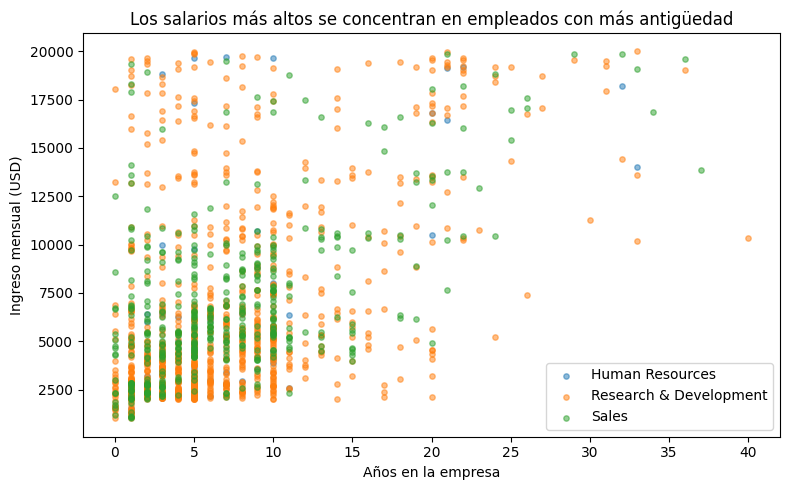

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for depto, grupo in df_limpio.groupby("Department"):
    ax.scatter(grupo["YearsAtCompany"], grupo["MonthlyIncome"], label=depto, alpha=0.5, s=15)
ax.set_xlabel("Años en la empresa")
ax.set_ylabel("Ingreso mensual (USD)")
ax.set_title("Los salarios más altos se concentran en empleados con más antigüedad")
ax.legend()
plt.tight_layout()
plt.savefig("grafico_dispersion.png", dpi=120)
plt.show()

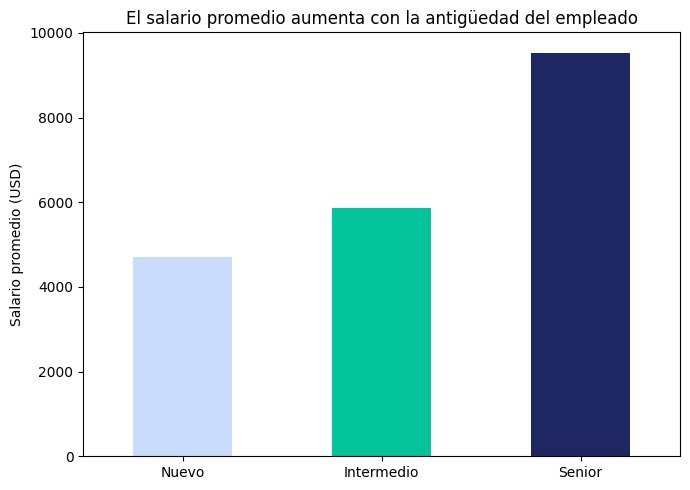

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
por_antiguedad.plot(kind="bar", ax=ax, color=["#CADCFC", "#02C39A", "#1E2761"])
ax.set_ylabel("Salario promedio (USD)")
ax.set_title("El salario promedio aumenta con la antigüedad del empleado")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafico_barras.png", dpi=120)
plt.show()

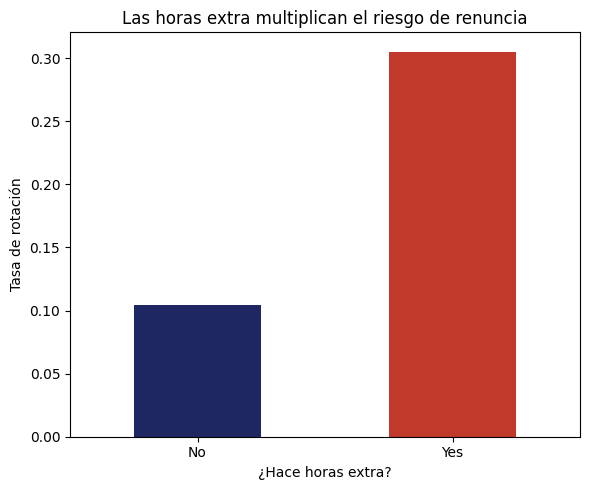

Multiplicador de riesgo (OverTime=Yes vs. No): 2.93x


In [17]:
tasa_por_overtime = df_limpio.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean())

fig, ax = plt.subplots(figsize=(6, 5))
tasa_por_overtime.plot(kind="bar", ax=ax, color=["#1E2761", "#C0392B"])
ax.set_ylabel("Tasa de rotación")
ax.set_title("Las horas extra multiplican el riesgo de renuncia")
ax.set_xlabel("¿Hace horas extra?")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafico_overtime.png", dpi=120)
plt.show()

multiplicador = tasa_por_overtime["Yes"] / tasa_por_overtime["No"]
print(f"Multiplicador de riesgo (OverTime=Yes vs. No): {multiplicador:.2f}x")

In [18]:
print("=== Verificación contra el dashboard ===")
print(f"CostoTotalNomina:        ${costo_total_nomina:,.2f}")
print(f"SalarioPromedio:         ${salario_promedio:,.2f}")
print(f"TasaRotacion:            {tasa_rotacion:.2%}")
print(f"EmpleadosQueRenunciaron: {empleados_que_renunciaron}")
print()
print("Filas finales:", df_limpio.shape[0], "| Columnas finales:", df_limpio.shape[1])

=== Verificación contra el dashboard ===
CostoTotalNomina:        $9,559,309.00
SalarioPromedio:         $6,502.93
TasaRotacion:            16.12%
EmpleadosQueRenunciaron: 237

Filas finales: 1470 | Columnas finales: 35


In [19]:
df_limpio.to_csv("dataset_nomina_limpio.csv", index=False)
print("Exportado: dataset_nomina_limpio.csv")

resumen = pd.DataFrame({
    "Indicador": ["CostoTotalNomina", "SalarioPromedio", "TasaRotacion", "EmpleadosQueRenunciaron"],
    "Valor": [costo_total_nomina, salario_promedio, tasa_rotacion, empleados_que_renunciaron],
})
resumen.to_csv("resumen_indicadores.csv", index=False)
print("Exportado: resumen_indicadores.csv")

Exportado: dataset_nomina_limpio.csv
Exportado: resumen_indicadores.csv


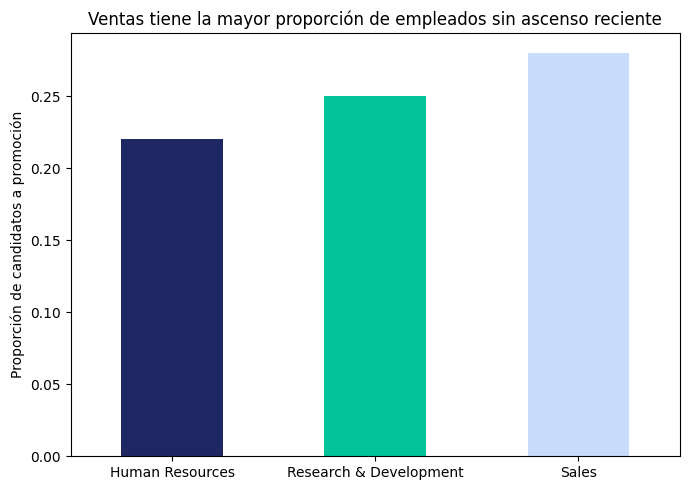

                        Cantidad  Proporción
Department                                  
Human Resources               14        0.22
Research & Development       236        0.25
Sales                        123        0.28


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
candidatos_por_depto["Proporción"].plot(kind="bar", ax=ax, color=["#1E2761", "#02C39A", "#CADCFC"])
ax.set_ylabel("Proporción de candidatos a promoción")
ax.set_title("Ventas tiene la mayor proporción de empleados sin ascenso reciente")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafico_promocion.png", dpi=120)
plt.show()

print(candidatos_por_depto)

In [21]:
df_limpio.to_csv("dataset_nomina_limpio.csv", index=False)
print("Exportado: dataset_nomina_limpio.csv")

resumen = pd.DataFrame({
    "Indicador": ["CostoTotalNomina", "SalarioPromedio", "TasaRotacion", "EmpleadosQueRenunciaron"],
    "Valor": [costo_total_nomina, salario_promedio, tasa_rotacion, empleados_que_renunciaron],
})
resumen.to_csv("resumen_indicadores.csv", index=False)
print("Exportado: resumen_indicadores.csv")

Exportado: dataset_nomina_limpio.csv
Exportado: resumen_indicadores.csv


In [22]:
print(df_limpio.columns.tolist())
print("Total de columnas:", df_limpio.shape[1])

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Banda salarial', 'Grupo de antigüedad', 'CandidatoPromocion']
Total de columnas: 35
